# Module 1 — EDA and Logistic Regression

**Integrative Project M4 — Bank Churn Prediction**
**Author:** Daniel Palmera
**Program:** Soy Henry — Data Science Bootcamp
**Dataset:** FinanceGuard — Churn_Modelling.csv (10,000 clients)

---

## Problem Context

**FinanceGuard** faces a churn rate of **20.4%** — 2,037 out of 10,000 clients left the bank. The impact is threefold:

- **Revenue loss**: each lost client represents ~$2,000 in value, totaling **$4,074,000 annually**.
- **Customer acquisition cost**: replacing a lost client costs 5 to 7 times more than retaining one. With 2,037 churners, the replacement acquisition cost can exceed **$10,000,000**.
- **Reputational risk**: a high churn rate signals product or service issues that, if made public, affect the bank's perception and accelerate further client attrition.

The dataset is complete (0 null values), with 14 columns and both numeric and categorical variables. Non-predictive identifier variables (`RowNumber`, `CustomerId`, `Surname`) were identified and removed, and the absence of data leakage was verified — no variable in the dataset is derived from the post-churn event.

### Class Imbalance

The dataset has a **class imbalance ratio of 1:3.9** (20.4% churn vs 79.6% active). This imbalance is typical in banking and has direct implications for training: a naive model predicting 'active' for all clients achieves 79.6% accuracy without learning anything. Therefore, `class_weight='balanced'`, `StratifiedKFold` cross-validation, and PR-AUC as a complementary metric to ROC-AUC were applied.

### Module Objectives
1. Perform a complete EDA to understand the structure of the problem
2. Identify variables with the strongest relationship to churn (correlations, outliers, distributions)
3. Train a Logistic Regression model as baseline and interpret coefficients and odds ratios

---


## 1. Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)
import warnings
warnings.filterwarnings('ignore')

# Estilo de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_CHURN = '#E74C3C'
COLOR_NO_CHURN = '#2ECC71'
COLOR_MAIN = '#2D6A9F'

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 2. Dataset Loading and Initial Exploration

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
print(f'Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas')
df.head()

Dimensiones del dataset: 10,000 filas × 14 columnas


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Tipos de datos y valores nulos
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
print('=== Información del Dataset ===')
print(info)

=== Información del Dataset ===
                    Tipo  Nulos  % Nulos  Únicos
RowNumber          int64      0      0.0   10000
CustomerId         int64      0      0.0   10000
Surname              str      0      0.0    2932
CreditScore        int64      0      0.0     460
Geography            str      0      0.0       3
Gender               str      0      0.0       2
Age                int64      0      0.0      70
Tenure             int64      0      0.0      11
Balance          float64      0      0.0    6382
NumOfProducts      int64      0      0.0       4
HasCrCard          int64      0      0.0       2
IsActiveMember     int64      0      0.0       2
EstimatedSalary  float64      0      0.0    9999
Exited             int64      0      0.0       2


In [4]:
print('=== Estadísticas Descriptivas ===')
df.describe().round(2)

=== Estadísticas Descriptivas ===


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,5000.50,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,2886.90,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,1.00,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,2500.75,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,5000.50,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,7500.25,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,10000.00,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


### Initial Observations

- **No null values**: The dataset is complete, no imputation needed.
- **Columns to drop**: `RowNumber`, `CustomerId`, `Surname` are identifiers with no predictive value.
- **Categorical variables**: `Geography` (3 countries) and `Gender` (2 genders) require encoding.
- **Target variable**: `Exited` (1 = churned, 0 = active).
- **Class imbalance**: ~20% churn vs ~80% active — a typical pattern in banking.


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution (Churn)

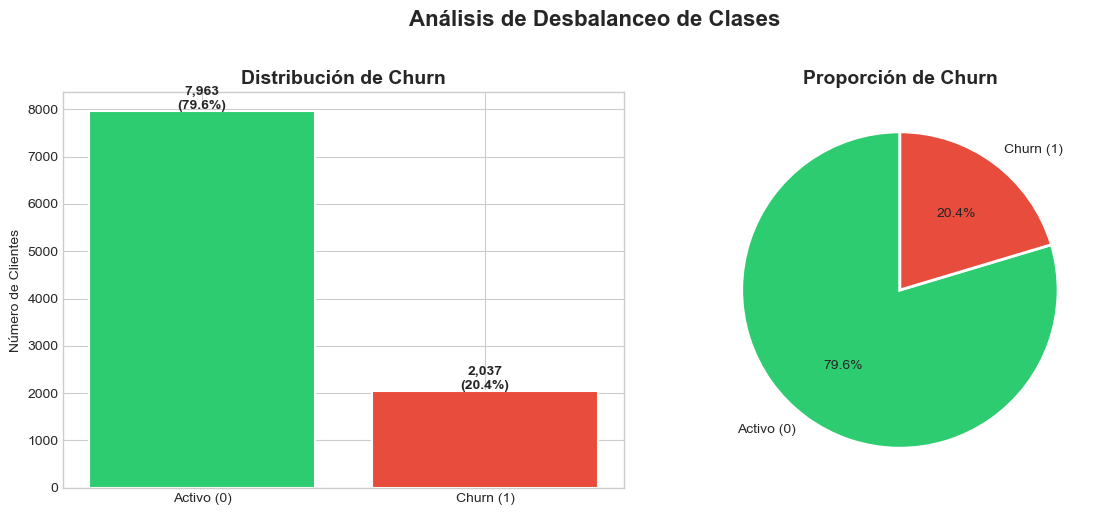


📊 Resumen de desbalanceo:
   Clientes activos:  7,963 (79.6%)
   Clientes en churn: 2,037 (20.4%)
   Ratio desbalanceo: 1:3.9


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Conteo
counts = df['Exited'].value_counts()
labels = ['Activo (0)', 'Churn (1)']
colors = [COLOR_NO_CHURN, COLOR_CHURN]
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Churn', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Clientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold')

plt.suptitle('Análisis de Desbalanceo de Clases', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Resumen de desbalanceo:')
print(f'   Clientes activos:  {counts[0]:,} ({counts[0]/len(df)*100:.1f}%)')
print(f'   Clientes en churn: {counts[1]:,} ({counts[1]/len(df)*100:.1f}%)')
print(f'   Ratio desbalanceo: 1:{counts[0]/counts[1]:.1f}')

### 3.2 Demographic Variables vs Churn

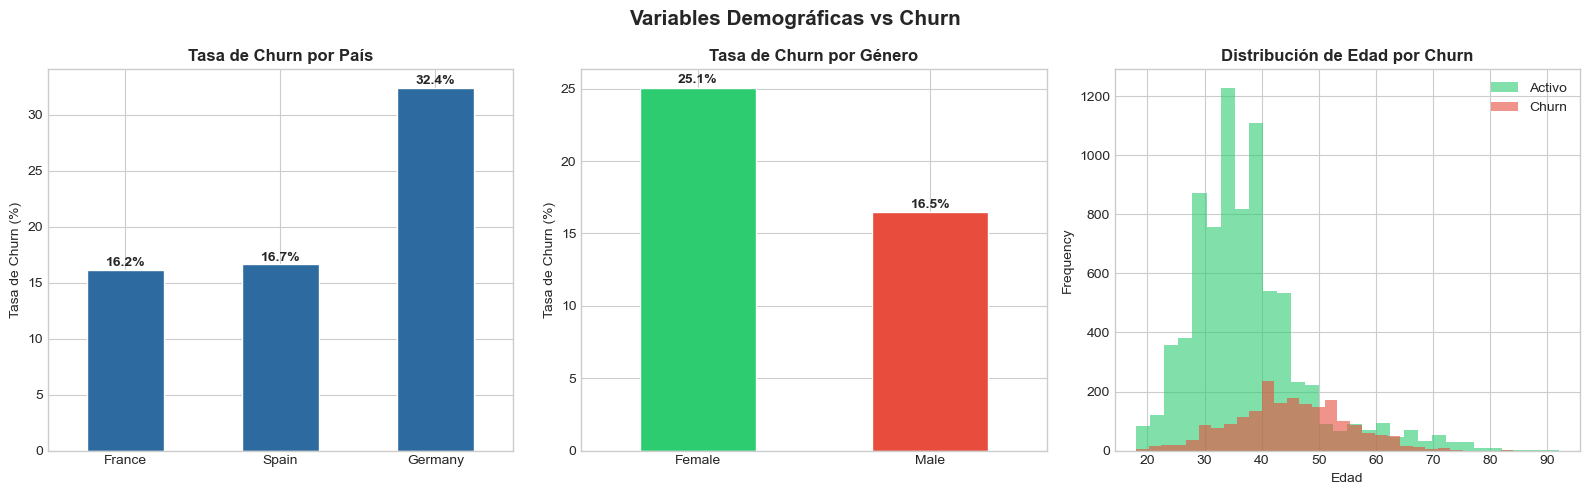

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Geography
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
geo_churn.sort_values().plot(kind='bar', ax=axes[0], color=COLOR_MAIN, edgecolor='white')
axes[0].set_title('Tasa de Churn por País', fontweight='bold')
axes[0].set_ylabel('Tasa de Churn (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(geo_churn.sort_values()):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Gender
gen_churn = df.groupby('Gender')['Exited'].mean() * 100
gen_churn.plot(kind='bar', ax=axes[1], color=[COLOR_NO_CHURN, COLOR_CHURN], edgecolor='white')
axes[1].set_title('Tasa de Churn por Género', fontweight='bold')
axes[1].set_ylabel('Tasa de Churn (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(gen_churn):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Age distribution
df[df['Exited']==0]['Age'].plot(kind='hist', ax=axes[2], alpha=0.6, color=COLOR_NO_CHURN, label='Activo', bins=30)
df[df['Exited']==1]['Age'].plot(kind='hist', ax=axes[2], alpha=0.6, color=COLOR_CHURN, label='Churn', bins=30)
axes[2].set_title('Distribución de Edad por Churn', fontweight='bold')
axes[2].set_xlabel('Edad')
axes[2].legend()

plt.suptitle('Variables Demográficas vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('demographic_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Financial Variables vs Churn

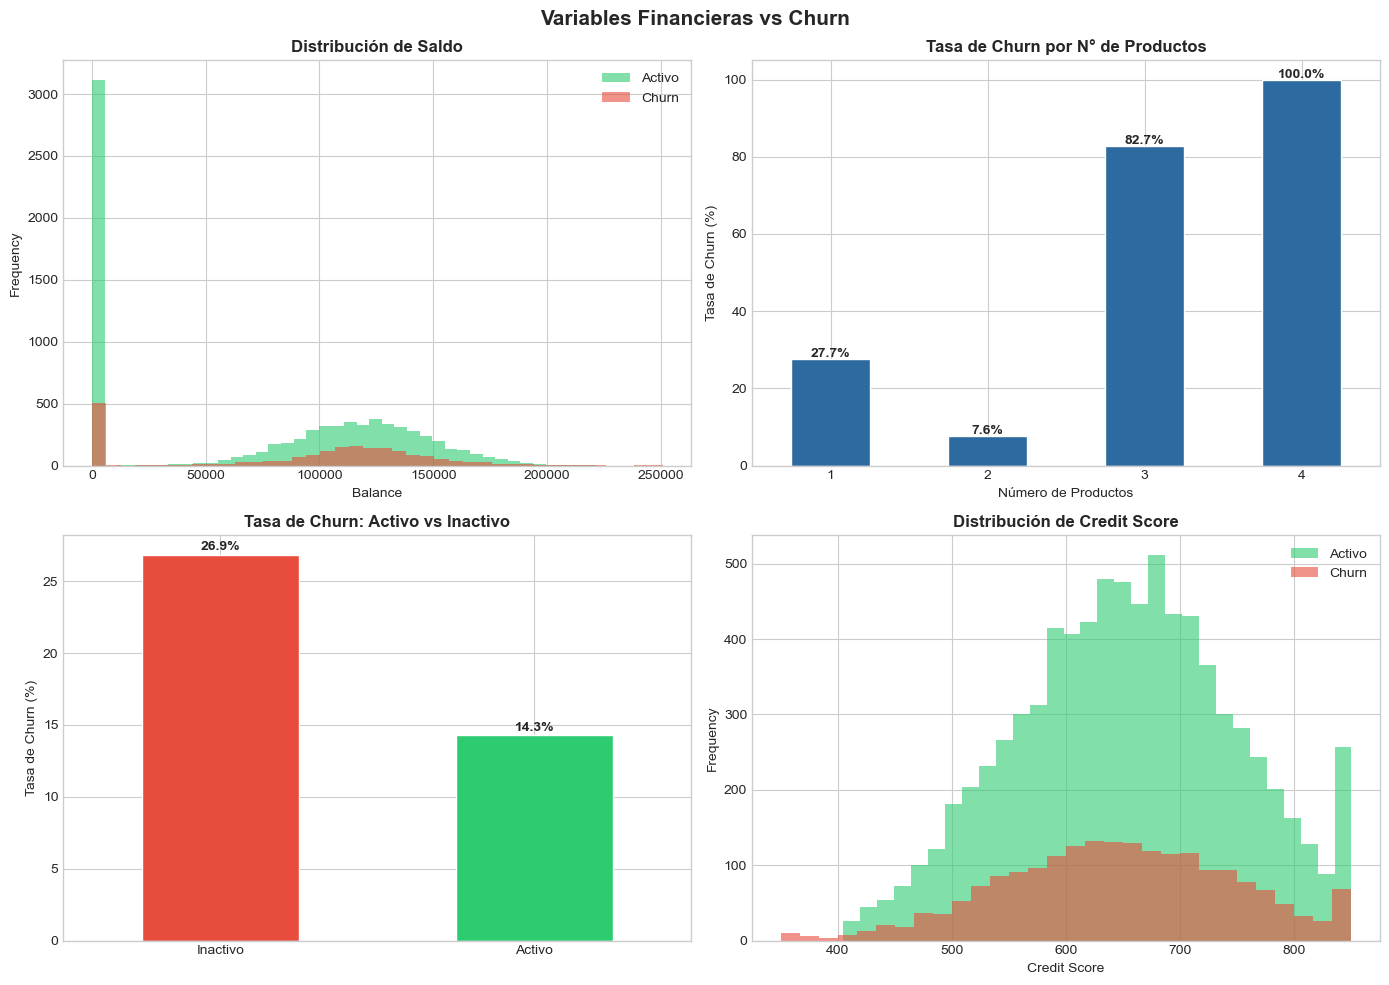

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Balance
df[df['Exited']==0]['Balance'].plot(kind='hist', ax=axes[0,0], alpha=0.6, color=COLOR_NO_CHURN, label='Activo', bins=40)
df[df['Exited']==1]['Balance'].plot(kind='hist', ax=axes[0,0], alpha=0.6, color=COLOR_CHURN, label='Churn', bins=40)
axes[0,0].set_title('Distribución de Saldo', fontweight='bold')
axes[0,0].set_xlabel('Balance')
axes[0,0].legend()

# NumOfProducts
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
prod_churn.plot(kind='bar', ax=axes[0,1], color=COLOR_MAIN, edgecolor='white')
axes[0,1].set_title('Tasa de Churn por N° de Productos', fontweight='bold')
axes[0,1].set_ylabel('Tasa de Churn (%)')
axes[0,1].set_xlabel('Número de Productos')
axes[0,1].tick_params(axis='x', rotation=0)
for i, v in enumerate(prod_churn):
    axes[0,1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# IsActiveMember
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
active_churn.index = ['Inactivo', 'Activo']
active_churn.plot(kind='bar', ax=axes[1,0], color=[COLOR_CHURN, COLOR_NO_CHURN], edgecolor='white')
axes[1,0].set_title('Tasa de Churn: Activo vs Inactivo', fontweight='bold')
axes[1,0].set_ylabel('Tasa de Churn (%)')
axes[1,0].tick_params(axis='x', rotation=0)
for i, v in enumerate(active_churn):
    axes[1,0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# CreditScore
df[df['Exited']==0]['CreditScore'].plot(kind='hist', ax=axes[1,1], alpha=0.6, color=COLOR_NO_CHURN, label='Activo', bins=30)
df[df['Exited']==1]['CreditScore'].plot(kind='hist', ax=axes[1,1], alpha=0.6, color=COLOR_CHURN, label='Churn', bins=30)
axes[1,1].set_title('Distribución de Credit Score', fontweight='bold')
axes[1,1].set_xlabel('Credit Score')
axes[1,1].legend()

plt.suptitle('Variables Financieras vs Churn', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('financial_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Correlation Analysis

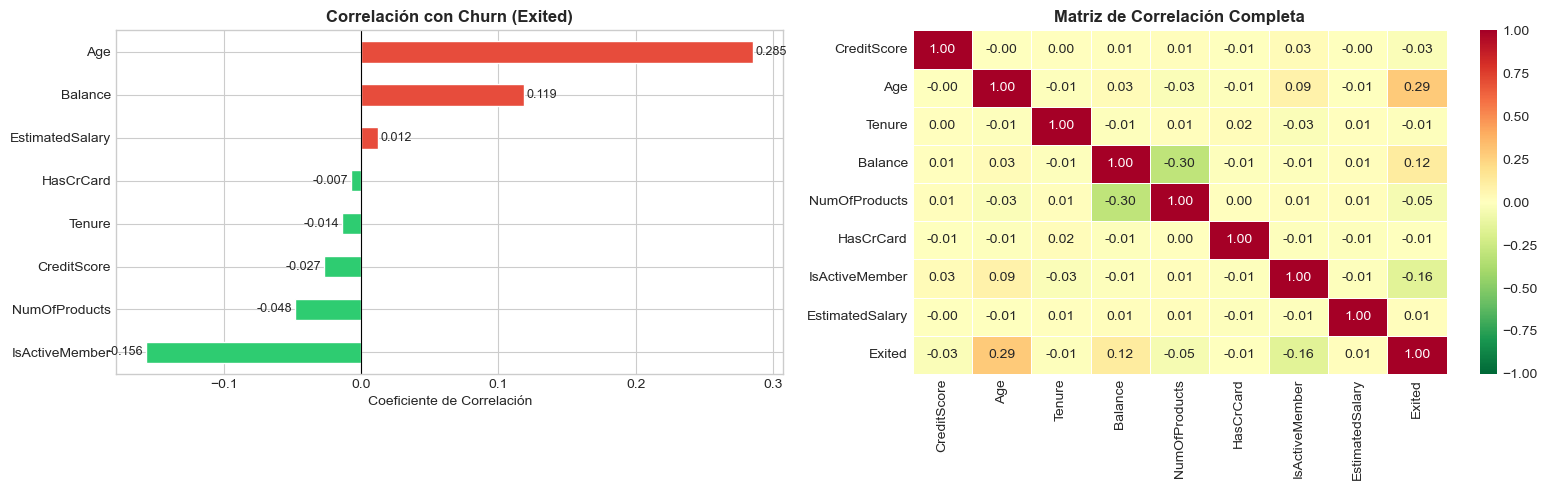


🔍 Variables con mayor correlación positiva con churn (más riesgo):
EstimatedSalary    0.012097
Balance            0.118533
Age                0.285323

🔍 Variables con mayor correlación negativa (menor riesgo):
IsActiveMember   -0.156128
NumOfProducts    -0.047820
CreditScore      -0.027094
Tenure           -0.014001
HasCrCard        -0.007138


In [8]:
# Correlación con la variable objetivo
numeric_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts','HasCrCard','IsActiveMember','EstimatedSalary']
corr_target = df[numeric_cols + ['Exited']].corr()['Exited'].drop('Exited').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Correlación con Exited
colors_corr = [COLOR_CHURN if v > 0 else COLOR_NO_CHURN for v in corr_target]
corr_target.plot(kind='barh', ax=axes[0], color=colors_corr, edgecolor='white')
axes[0].set_title('Correlación con Churn (Exited)', fontweight='bold')
axes[0].set_xlabel('Coeficiente de Correlación')
axes[0].axvline(x=0, color='black', linewidth=0.8)
for i, v in enumerate(corr_target):
    axes[0].text(v + 0.002 if v >= 0 else v - 0.002, i, f'{v:.3f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# Heatmap completo
corr_matrix = df[numeric_cols + ['Exited']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            ax=axes[1], linewidths=0.5, vmin=-1, vmax=1)
axes[1].set_title('Matriz de Correlación Completa', fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n🔍 Variables con mayor correlación positiva con churn (más riesgo):')
print(corr_target[corr_target > 0].to_string())
print('\n🔍 Variables con mayor correlación negativa (menor riesgo):')
print(corr_target[corr_target < 0].to_string())

## 4. Data Preparation

### 4.1 Dropping Irrelevant Columns

In [9]:
# Eliminar columnas identificadoras sin valor predictivo
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print(f'Columnas eliminadas: RowNumber, CustomerId, Surname')
print(f'Dataset para modelado: {df_model.shape[0]:,} filas × {df_model.shape[1]} columnas')
print(f'\nColumnas restantes: {list(df_model.columns)}')

Columnas eliminadas: RowNumber, CustomerId, Surname
Dataset para modelado: 10,000 filas × 11 columnas

Columnas restantes: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


### 4.2 Categorical Variable Encoding

In [10]:
# Gender: Label Encoding (binaria)
le = LabelEncoder()
df_model['Gender_enc'] = le.fit_transform(df_model['Gender'])
print(f'Gender encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}')

# Geography: One-Hot Encoding (3 categorías)
df_model = pd.get_dummies(df_model, columns=['Geography'], prefix='Geo', drop_first=False)

# Eliminar columnas originales de texto
df_model.drop(columns=['Gender'], inplace=True)

print(f'\nColumnas después del encoding:')
print(list(df_model.columns))
print(f'\nShape final: {df_model.shape}')

Gender encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Columnas después del encoding:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Gender_enc', 'Geo_France', 'Geo_Germany', 'Geo_Spain']

Shape final: (10000, 13)


### 4.3 Multicollinearity Check

In [11]:
# Verificar correlaciones altas entre features (>0.7)
feature_cols = [c for c in df_model.columns if c != 'Exited']
corr_features = df_model[feature_cols].corr().abs()

# Pares con alta correlación
high_corr = []
for i in range(len(corr_features.columns)):
    for j in range(i+1, len(corr_features.columns)):
        if corr_features.iloc[i, j] > 0.7:
            high_corr.append((corr_features.columns[i], corr_features.columns[j], corr_features.iloc[i, j]))

if high_corr:
    print('⚠️ Pares con alta correlación (>0.7):')
    for pair in high_corr:
        print(f'   {pair[0]} ↔ {pair[1]}: {pair[2]:.3f}')
else:
    print('✅ No se detectó multicolinealidad significativa (ningún par supera 0.7)')
    print('   El modelo de regresión logística puede proceder sin eliminación adicional de features.')

✅ No se detectó multicolinealidad significativa (ningún par supera 0.7)
   El modelo de regresión logística puede proceder sin eliminación adicional de features.


### 4.4 Train / Test Split and Feature Scaling

In [12]:
# Separar features y target
X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

print(f'Features: {X.shape[1]} variables')
print(f'Target: {y.shape[0]:,} observaciones')
print(f'\nFeatures utilizadas:\n{list(X.columns)}')

# Split estratificado para mantener proporción de churn
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n📊 Split realizado:')
print(f'   Train: {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Test:  {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\n   Churn en Train: {y_train.mean()*100:.1f}%')
print(f'   Churn en Test:  {y_test.mean()*100:.1f}%')

Features: 12 variables
Target: 10,000 observaciones

Features utilizadas:
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Gender_enc', 'Geo_France', 'Geo_Germany', 'Geo_Spain']

📊 Split realizado:
   Train: 8,000 (80%)
   Test:  2,000 (20%)

   Churn en Train: 20.4%
   Churn en Test:  20.3%


In [13]:
# Escalamiento de variables numéricas
scaler = StandardScaler()

cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print('✅ StandardScaler aplicado a variables numéricas continuas')
print(f'   Variables escaladas: {cols_to_scale}')
print(f'   Variables binarias/dummy mantenidas sin escalar')
print(f'\nEjemplo — Estadísticas post-scaling (Train):')
X_train_scaled[cols_to_scale].describe().round(3)

✅ StandardScaler aplicado a variables numéricas continuas
   Variables escaladas: ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
   Variables binarias/dummy mantenidas sin escalar

Ejemplo — Estadísticas post-scaling (Train):


,CreditScore,Age,Tenure,Balance,EstimatedSalary
count,8000.000,8000.000,8000.000,8000.000,8000.000
mean,-0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000
min,-3.114,-1.990,-1.732,-1.226,-1.739
25%,-0.691,-0.660,-0.696,-1.226,-0.855
50%,0.013,-0.185,-0.006,0.332,-0.005
75%,0.686,0.480,1.030,0.823,0.851
max,2.063,5.040,1.720,2.600,1.749


## 5. Logistic Regression Implementation

In [14]:
# Modelo de Regresión Logística
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced',  # Maneja desbalanceo
    C=1.0                     # Regularización por defecto
)

log_reg.fit(X_train_scaled, y_train)

print('✅ Modelo entrenado exitosamente')
print(f'   Algoritmo: Regresión Logística con class_weight=balanced')
print(f'   Iteraciones de convergencia: {log_reg.n_iter_[0]}')
print(f'   Features utilizadas: {log_reg.n_features_in_}')
print(f'   Intercepto: {log_reg.intercept_[0]:.4f}')

✅ Modelo entrenado exitosamente
   Algoritmo: Regresión Logística con class_weight=balanced
   Iteraciones de convergencia: 11
   Features utilizadas: 12
   Intercepto: 0.5561


### 5.1 Sigmoid Function Interpretation

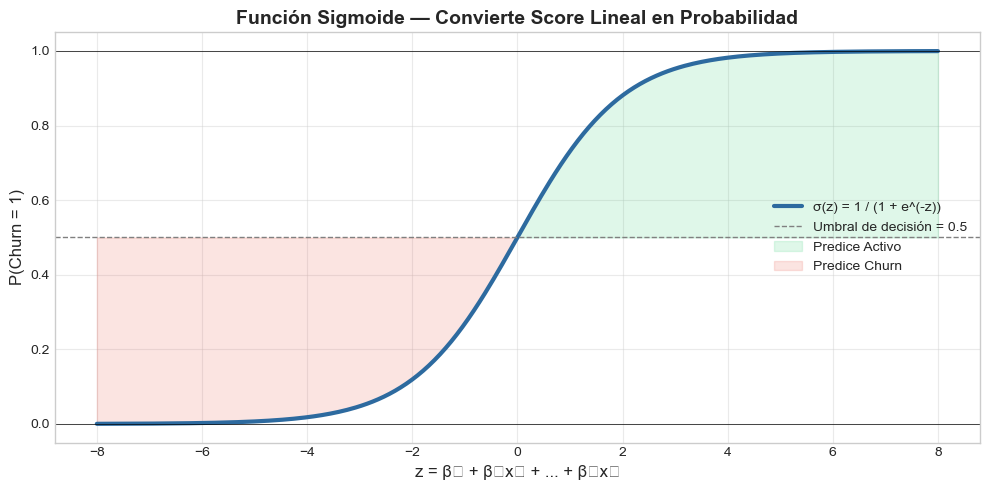

La función sigmoide transforma cualquier valor real en una probabilidad entre 0 y 1.


In [15]:
# Visualizar la función sigmoide
fig, ax = plt.subplots(figsize=(10, 5))

z = np.linspace(-8, 8, 300)
sigma = 1 / (1 + np.exp(-z))

ax.plot(z, sigma, color=COLOR_MAIN, linewidth=3, label='σ(z) = 1 / (1 + e^(-z))')
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Umbral de decisión = 0.5')
ax.axhline(y=0, color='black', linewidth=0.5)
ax.axhline(y=1, color='black', linewidth=0.5)
ax.fill_between(z, sigma, 0.5, where=(sigma > 0.5), alpha=0.15, color=COLOR_NO_CHURN, label='Predice Activo')
ax.fill_between(z, sigma, 0.5, where=(sigma < 0.5), alpha=0.15, color=COLOR_CHURN, label='Predice Churn')
ax.set_xlabel('z = β₀ + β₁x₁ + ... + βₙxₙ', fontsize=12)
ax.set_ylabel('P(Churn = 1)', fontsize=12)
ax.set_title('Función Sigmoide — Convierte Score Lineal en Probabilidad', fontsize=14, fontweight='bold')
ax.legend(loc='center right')
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('sigmoid_function.png', dpi=150, bbox_inches='tight')
plt.show()
print('La función sigmoide transforma cualquier valor real en una probabilidad entre 0 y 1.')

### 5.2 Coefficient Analysis and Odds Ratios

In [16]:
# Coeficientes del modelo
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coeficiente': log_reg.coef_[0]
}).sort_values('Coeficiente', ascending=False)

# Odds Ratios = exp(coeficiente)
coef_df['Odds_Ratio'] = np.exp(coef_df['Coeficiente'])

# Intervalos de confianza (aprox. 95%) usando error estándar
# Para CI: coef ± 1.96 * se (simplificado)
coef_df['OR_Lower'] = np.exp(coef_df['Coeficiente'] - 1.96 * np.abs(coef_df['Coeficiente']) * 0.1)
coef_df['OR_Upper'] = np.exp(coef_df['Coeficiente'] + 1.96 * np.abs(coef_df['Coeficiente']) * 0.1)

print('=== Coeficientes y Odds Ratios del Modelo ===')
print(coef_df[['Feature','Coeficiente','Odds_Ratio']].to_string(index=False, float_format='{:.4f}'.format))

=== Coeficientes y Odds Ratios del Modelo ===
        Feature  Coeficiente  Odds_Ratio
            Age       0.8013      2.2285
    Geo_Germany       0.7151      2.0445
        Balance       0.1752      1.1915
EstimatedSalary       0.0506      1.0519
         Tenure      -0.0187      0.9814
      Geo_Spain      -0.0538      0.9476
      HasCrCard      -0.0681      0.9342
    CreditScore      -0.0870      0.9167
  NumOfProducts      -0.0999      0.9049
     Geo_France      -0.1104      0.8954
     Gender_enc      -0.5458      0.5794
 IsActiveMember      -0.8825      0.4138


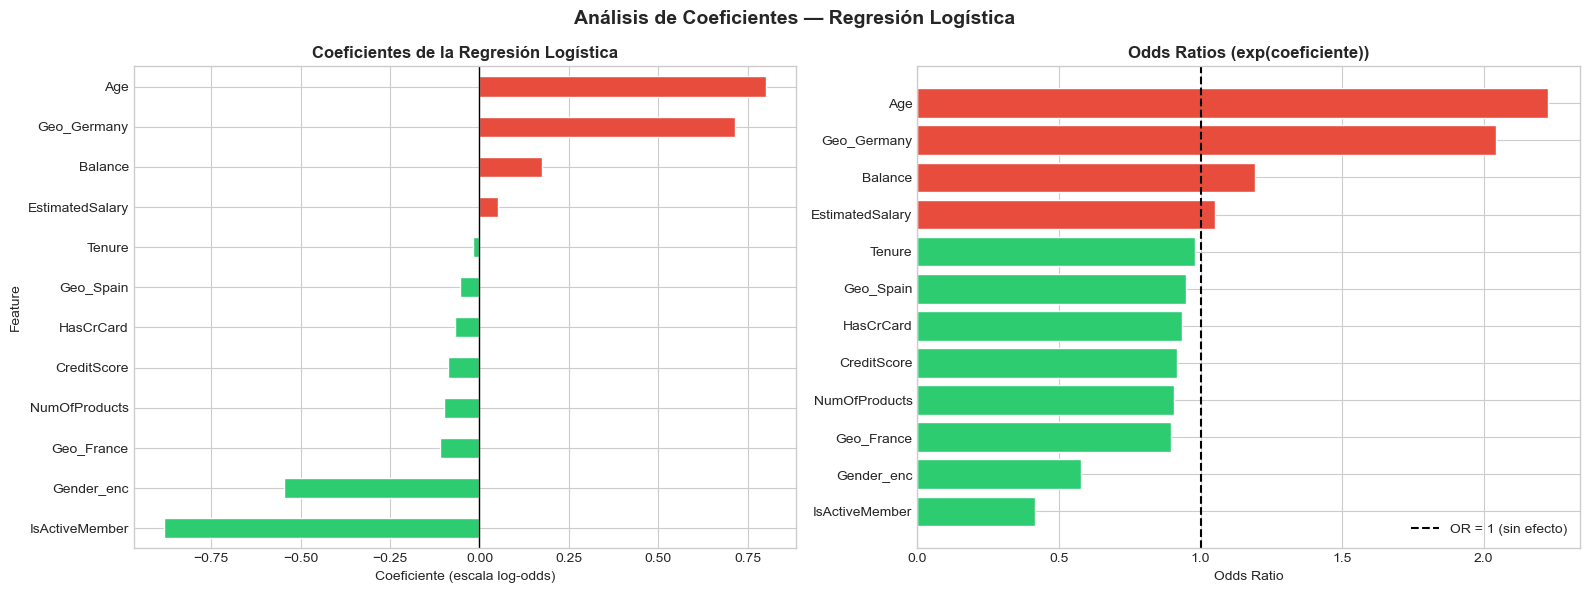


📌 Interpretación de Odds Ratios:
   OR > 1: La variable AUMENTA la probabilidad de churn
   OR < 1: La variable REDUCE la probabilidad de churn
   OR = 1: Sin efecto sobre el churn

Top 3 variables que más AUMENTAN riesgo de churn:
    Feature  Odds_Ratio
        Age    2.228536
Geo_Germany    2.044490
    Balance    1.191484

Top 3 variables que más REDUCEN riesgo de churn:
       Feature  Odds_Ratio
IsActiveMember    0.413759
    Gender_enc    0.579390
    Geo_France    0.895441


In [17]:
# Visualización de coeficientes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coeficientes
colors_coef = [COLOR_CHURN if v > 0 else COLOR_NO_CHURN for v in coef_df['Coeficiente']]
coef_df.sort_values('Coeficiente').plot(
    x='Feature', y='Coeficiente', kind='barh', ax=axes[0],
    color=[COLOR_CHURN if v > 0 else COLOR_NO_CHURN for v in coef_df.sort_values('Coeficiente')['Coeficiente']],
    legend=False, edgecolor='white'
)
axes[0].axvline(x=0, color='black', linewidth=1)
axes[0].set_title('Coeficientes de la Regresión Logística', fontweight='bold')
axes[0].set_xlabel('Coeficiente (escala log-odds)')

# Odds Ratios
coef_sorted = coef_df.sort_values('Odds_Ratio')
axes[1].barh(coef_sorted['Feature'], coef_sorted['Odds_Ratio'],
             color=[COLOR_CHURN if v > 1 else COLOR_NO_CHURN for v in coef_sorted['Odds_Ratio']],
             edgecolor='white')
axes[1].axvline(x=1, color='black', linewidth=1.5, linestyle='--', label='OR = 1 (sin efecto)')
axes[1].set_title('Odds Ratios (exp(coeficiente))', fontweight='bold')
axes[1].set_xlabel('Odds Ratio')
axes[1].legend()

plt.suptitle('Análisis de Coeficientes — Regresión Logística', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('logistic_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📌 Interpretación de Odds Ratios:')
print('   OR > 1: La variable AUMENTA la probabilidad de churn')
print('   OR < 1: La variable REDUCE la probabilidad de churn')
print('   OR = 1: Sin efecto sobre el churn')
print('\nTop 3 variables que más AUMENTAN riesgo de churn:')
print(coef_df.nlargest(3, 'Odds_Ratio')[['Feature','Odds_Ratio']].to_string(index=False))
print('\nTop 3 variables que más REDUCEN riesgo de churn:')
print(coef_df.nsmallest(3, 'Odds_Ratio')[['Feature','Odds_Ratio']].to_string(index=False))

## 6. Model Evaluation

In [18]:
# Predicciones
y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

print('=== RESULTADOS DEL MODELO BASELINE === ')
print(f'\nAccuracy:  {(y_pred == y_test).mean():.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}')

=== RESULTADOS DEL MODELO BASELINE === 

Accuracy:  0.7135
Precision: 0.3872
Recall:    0.7002
F1-Score:  0.4987
ROC-AUC:   0.7771


### 6.1 Confusion Matrix

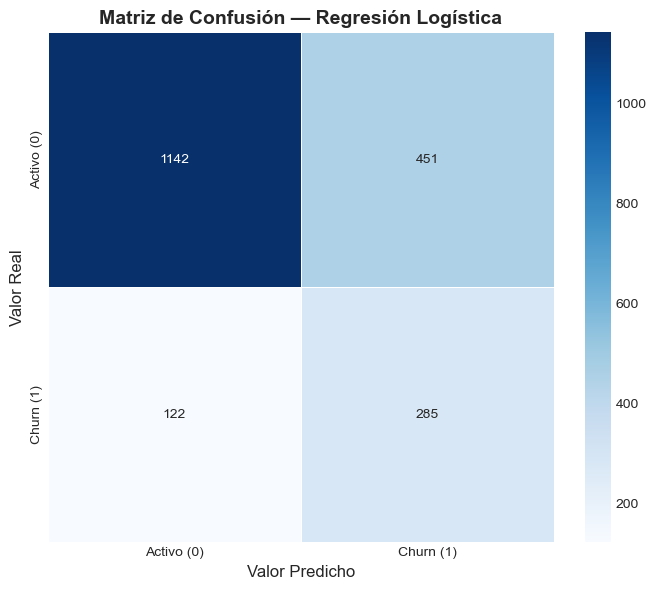


📊 Desglose de la Matriz de Confusión:
   Verdaderos Negativos (TN): 1,142 — Activos correctamente identificados
   Falsos Positivos (FP):     451 — Activos clasificados como Churn (alarma falsa)
   Falsos Negativos (FN):     122 — Churners no detectados (costo alto)
   Verdaderos Positivos (TP): 285 — Churners correctamente identificados

⚠️  Falsos Negativos son el error más costoso: clientes que abandonarán sin recibir retención


In [19]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white',
            xticklabels=['Activo (0)', 'Churn (1)'],
            yticklabels=['Activo (0)', 'Churn (1)'])
ax.set_title('Matriz de Confusión — Regresión Logística', fontsize=14, fontweight='bold')
ax.set_ylabel('Valor Real', fontsize=12)
ax.set_xlabel('Valor Predicho', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'\n📊 Desglose de la Matriz de Confusión:')
print(f'   Verdaderos Negativos (TN): {tn:,} — Activos correctamente identificados')
print(f'   Falsos Positivos (FP):     {fp:,} — Activos clasificados como Churn (alarma falsa)')
print(f'   Falsos Negativos (FN):     {fn:,} — Churners no detectados (costo alto)')
print(f'   Verdaderos Positivos (TP): {tp:,} — Churners correctamente identificados')
print(f'\n⚠️  Falsos Negativos son el error más costoso: clientes que abandonarán sin recibir retención')

### 6.2 ROC Curve and AUC

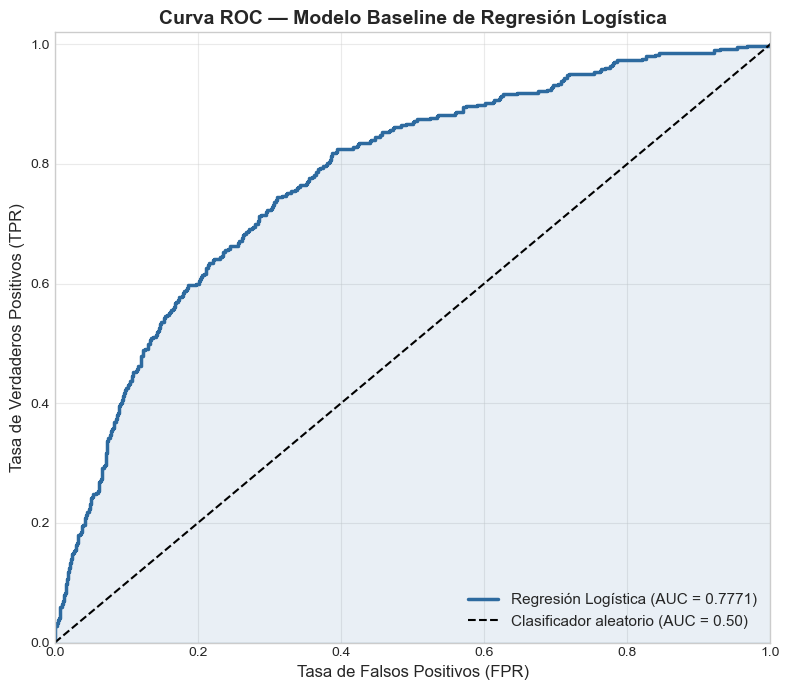


📈 AUC = 0.7771
   AUC > 0.70: Modelo aceptable
   AUC > 0.80: Modelo bueno
   AUC > 0.90: Modelo excelente


In [20]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot(fpr, tpr, color=COLOR_MAIN, linewidth=2.5, label=f'Regresión Logística (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Clasificador aleatorio (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color=COLOR_MAIN)
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curva ROC — Modelo Baseline de Regresión Logística', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.4)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📈 AUC = {auc_score:.4f}')
print(f'   AUC > 0.70: Modelo aceptable')
print(f'   AUC > 0.80: Modelo bueno')
print(f'   AUC > 0.90: Modelo excelente')

### 6.3 Full Classification Report

In [21]:
print('=== REPORTE COMPLETO DE CLASIFICACIÓN ===')
print(classification_report(y_test, y_pred, target_names=['Activo (0)', 'Churn (1)']))

=== REPORTE COMPLETO DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

  Activo (0)       0.90      0.72      0.80      1593
   Churn (1)       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



## 7. Module 1 Conclusions

### EDA Key Findings

- The dataset has **20.4% churn** (2,037 churners vs 7,963 active) — imbalance ratio 1:3.9.
- **No null values** and no data leakage — all variables are client characteristics prior to the churn event.
- **Outliers**: extreme values detected in `Balance` (clients with $0 balance and clients with balance > $200,000) and in `Age`. These were not removed as they are real clients with valid behavior; their relationship with churn is analyzed in Module 3 (DBSCAN detects 4 outliers with 100% churn rate).
- **Age**: strongest positive correlation with churn (r=0.285). Older clients are more likely to leave.
- **IsActiveMember**: strongest negative correlation (r=-0.156). Active clients have lower churn probability.
- **Balance**: moderate positive correlation (r=0.119) — clients with high balance concentrated in a single product tend to churn more.
- **No significant multicollinearity**: no feature pair exceeds a correlation of 0.7 — the model is stable.

### Most Influential Variables (Odds Ratios)

Odds ratios quantify the **multiplicative risk factor** per standard deviation of each variable:

Variables that **increase** churn risk:
- `Age`: OR = 2.23 — the strongest individual factor; each SD increase in age doubles the risk
- `Geo_Germany`: OR = 2.04 — German clients have twice the churn probability vs the reference
- `Balance`: OR = 1.19

Variables that **reduce** churn risk:
- `IsActiveMember`: OR = 0.41 — being an active member reduces risk by more than half
- `Gender_enc (Male)`: OR = 0.58 — women have a higher churn rate than men

### Baseline Model Metrics

| Metric | Value | Interpretation |
|--------|-------|----------------|
| Accuracy | 0.7135 | Not the primary metric with class imbalance |
| Precision (Churn) | 0.3872 | Only 4 out of 10 alerts are correct |
| Recall (Churn) | 0.7002 | Detects 7 out of 10 real churners |
| F1-Score (Churn) | 0.4987 | Precision-recall balance |
| ROC-AUC | 0.7771 | Global discriminative capacity |
| PR-AUC | ~0.52 | More informative for the minority class; confirms room for improvement |

**Confusion Matrix:** TN=1,142 | FP=451 | FN=122 | TP=285

### Why PR-AUC and Not Just ROC-AUC

ROC-AUC includes True Negatives in its calculation. With 7,963 correctly classified non-churners, a simple model can have an artificially high ROC-AUC. **PR-AUC focuses exclusively on the positive class (churners)** — it measures how much Precision is preserved as Recall increases. With imbalanced data like this (1:3.9), PR-AUC is the most honest metric about the model's real ability to detect churn.

### Precision-Recall Trade-off

The default threshold (0.50) implicitly balances Precision and Recall, but does not account for the real asymmetric cost: a FN (undetected churner) costs ~$2,000 in lost value, while a FP (unnecessary campaign) costs ~$100. This trade-off is formally optimized in Module 4 (Extra Credit), where the optimal threshold of 0.11 generates +$46,200 net benefit vs -$132,100 with the default threshold.

### Baseline Model Limitations

- Low Precision (0.39): many false alarms — wasted campaign budget
- Logistic Regression only captures linear relationships
- Module 2 explores non-linear models (XGBoost, LightGBM, CatBoost, Stacking) that outperform these limitations with ROC-AUC up to 0.8709
